# Milo Powell, Senior Thesis (May, 2025)
## Green Space and Asthma Prevalence in NYC
### Sections:
* [Code for Green space percentage in NYC ZIPCODE tabulation areas](#Code-for-Green-space-percentage-in-NYC-ZIPCODE-tabulation-areas)
* [Code for Asthma prevalence in NYC ZIPCODE tabulation areas](#Code-for-Asthma-prevalence-in-NYC-ZIPCODE-tabulation-areas)
* [Code for Asthma prevalence in Bronx ZIPCODE tabulation areas](#Code-for-Asthma-prevalence-in-Bronx-ZIPCODE-tabulation-areas)
* [Tree density calculations and NYC total correlation preparations](#Tree-density-calculations-and-NYC-total-correlation-preparations)
* [NYC Total Correlations, Graphs, and Maps](#NYC-Total-Correlations,-Graphs,-and-Maps)
* [The Bronx Correlations, Graphs, and Maps](#The-Bronx-Correlations,-Graphs,-and-Maps)

In [320]:
""" INSTALL DEPENDENCIES """

import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Code for Green space percentage in NYC ZIPCODE tabulation areas
### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [321]:
""" LOADING CSV FILES FOR ZIPCODE AND GREENSPACE AREAS """

# Load green space size and Zip code areas for US csv
green_space_df = pd.read_csv('green_space.csv')
zip_code_sqmi_df = pd.read_csv('zip_code_area.csv')

# Convert all zipcode columns to type str and strip spaces
zip_code_sqmi_df['ZIPCODE'] = zip_code_sqmi_df['ZIPCODE'].apply(lambda x: str(x).strip())

# Print heading of each df
print(green_space_df.head())
print(zip_code_sqmi_df.head())

print(green_space_df.dtypes)
print(zip_code_sqmi_df.dtypes)

   ACRES ZIPCODE
0  0.545   10034
1  2.213   10457
2  0.114   10460
3  6.219   11373
4  3.312   10021
  ZIPCODE  ALAND_SQMI
0     601      64.416
1     602      30.327
2     603      34.356
3     606      44.334
4     610      37.124
ACRES      float64
ZIPCODE     object
dtype: object
ZIPCODE        object
ALAND_SQMI    float64
dtype: object


In [322]:
""" SEPERATING ZIPCODES AND PARKS IN GREEN_SPACE CSV """

# String split of all zipcodes in column ZIPCODE
green_space_df['ZIPCODE'] = green_space_df['ZIPCODE'].str.split(',')

# Initialize num_zip for division of acreage later
num_zips = green_space_df['ZIPCODE'].str.len()

# Acres for each row divided by number of zips included in the entry
green_space_df['ACRES'] = green_space_df['ACRES'] / num_zips

# Creates new row for each row with multiple entries
green_space_df_exploded = green_space_df.explode('ZIPCODE').reset_index(drop=True)

# Strips white space for each row in column 'ZIPCODE'
green_space_df_exploded['ZIPCODE'] = green_space_df_exploded['ZIPCODE'].str.strip()

print(green_space_df_exploded)
green_space_df_exploded.to_csv('green_space_exploded.csv', index=False)

         ACRES ZIPCODE
0       0.5450   10034
1       2.2130   10457
2       0.1140   10460
3       6.2190   11373
4       3.3120   10021
...        ...     ...
2285  224.4225   11367
2286  224.4225   11368
2287  109.6090   11434
2288    1.3950   10467
2289    1.7740   11233

[2290 rows x 2 columns]


In [323]:
""" CREATE DF WITH CONGRUENT & CLEANED ZIPCODES BTWN df'S  """

print(green_space_df_exploded.dtypes)
print(zip_code_sqmi_df.dtypes)

filtered_zip_codes_df = zip_code_sqmi_df[zip_code_sqmi_df['ZIPCODE'].isin(green_space_df_exploded['ZIPCODE'])]

print(filtered_zip_codes_df)

ACRES      float64
ZIPCODE     object
dtype: object
ZIPCODE        object
ALAND_SQMI    float64
dtype: object
     ZIPCODE  ALAND_SQMI
2583   10001       0.624
2584   10002       0.822
2585   10003       0.572
2586   10004       0.456
2587   10005       0.073
...      ...         ...
2977   11580       3.888
2982   11691       2.683
2983   11692       1.016
2984   11693       0.989
2985   11694       1.747

[182 rows x 2 columns]


In [324]:
""" CLEAN GREEN SPACE DF BY COMBINING ALL ROWS WITH DUPLICATE INDEX 
    & CHANGE ACREAGE TO SQUARE MILEAGE """

# Groupby based on ZIPCODE
green_space_combined_df = green_space_df_exploded.groupby('ZIPCODE', as_index=False).sum()

# Check for the df
print(green_space_combined_df.head())

# Remove the first row, since it has an inaccurate zipcode
green_space_combined_df = green_space_combined_df.drop(green_space_combined_df.index[0])

# Convert acres to sqmi for ratio caluclation (sqmi = acres / 640)
green_space_combined_df['SQUARE_MILES'] = green_space_combined_df['ACRES'] / 640

# Check for the df
print(green_space_combined_df.head())

# Save the df as a new csv 'green_space_df.csv'
green_space_combined_df.to_csv('green_space_df.csv', index=False)


  ZIPCODE      ACRES
0       1  95.225750
1   10001   8.778333
2   10002  90.192000
3   10003  13.712000
4   10004  12.684000
  ZIPCODE      ACRES  SQUARE_MILES
1   10001   8.778333      0.013716
2   10002  90.192000      0.140925
3   10003  13.712000      0.021425
4   10004  12.684000      0.019819
5   10005   0.117000      0.000183


In [325]:
""" MERGE ZIPCODE AND GREENSPACE FOR RATIO CALCULATION """

# Merge based on zipcode and add square_miles of green space
green_merge_df = pd.merge(filtered_zip_codes_df, green_space_combined_df[['ZIPCODE', 'SQUARE_MILES']], on='ZIPCODE', how='left')

print(green_merge_df)

    ZIPCODE  ALAND_SQMI  SQUARE_MILES
0     10001       0.624      0.013716
1     10002       0.822      0.140925
2     10003       0.572      0.021425
3     10004       0.456      0.019819
4     10005       0.073      0.000183
..      ...         ...           ...
177   11580       3.888      0.023286
178   11691       2.683      0.804442
179   11692       1.016      1.003775
180   11693       0.989      0.319487
181   11694       1.747      0.558555

[182 rows x 3 columns]


In [326]:
""" COMPLETE RATIO CALCULATION FOR PERCENTAGE OF GREEN SPACE IN EACH ZIPCODE """

# Percentage calculation: (green space / area square miles) * 100
green_merge_df['PERCENTAGE_GREENSPACE'] = (green_merge_df['SQUARE_MILES'] / green_merge_df['ALAND_SQMI']) * 100

print(green_merge_df.head())

# Drop unnecessary columns for later correlation
green_merge_df = green_merge_df.drop(columns={'ALAND_SQMI', 'SQUARE_MILES'})

print(green_merge_df.head())
print(green_merge_df.info())

  ZIPCODE  ALAND_SQMI  SQUARE_MILES  PERCENTAGE_GREENSPACE
0   10001       0.624      0.013716               2.198100
1   10002       0.822      0.140925              17.144161
2   10003       0.572      0.021425               3.745629
3   10004       0.456      0.019819               4.346217
4   10005       0.073      0.000183               0.250428
  ZIPCODE  PERCENTAGE_GREENSPACE
0   10001               2.198100
1   10002              17.144161
2   10003               3.745629
3   10004               4.346217
4   10005               0.250428
<class 'pandas.core.frame.DataFrame'>
Int64Index: 182 entries, 0 to 181
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ZIPCODE                182 non-null    object 
 1   PERCENTAGE_GREENSPACE  182 non-null    float64
dtypes: float64(1), object(1)
memory usage: 4.3+ KB
None


In [327]:
""" ROUND PERCENTAGES TO 2 DECIMAL POINTS AND SAVE DF AS A NEW CSV """

# Round column 'PERCENTAGE_GREENSPACE' to two decimal points
green_merge_df['PERCENTAGE_GREENSPACE'] = green_merge_df['PERCENTAGE_GREENSPACE'].round(2)

green_merge_df.to_csv('new_percentage_green_space.csv', index=False)

## Code for Asthma prevalence in NYC ZIPCODE tabulation areas
### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [329]:
""" LOAD CSV FILE FOR ASTHMA RATES IN NYS """

# Load csv for asthma rates in NYS
new_df = pd.read_csv('AD-SubCountyData.csv', low_memory=False)

# Drop unnecessary columns for this study from the df
df = new_df.drop(columns=['Unnamed: 0', 'Unnamed: 4', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15'])

print(df.head())

                                          Unnamed: 1  Unnamed: 2  \
0                                                NaN         NaN   
1                                          Indicator  Data Years   
2  Asthma emergency department visit rate per 10,...   2016-2018   
3  Asthma emergency department visit rate per 10,...   2016-2018   
4  Asthma emergency department visit rate per 10,...   2016-2018   

       Unnamed: 3 Unnamed: 5     Unnamed: 8                Unnamed: 9  
0             NaN        NaN            NaN                       NaN  
1          Region   ZIP Code  ZIP Code Rate                 Rate Unit  
2  Capital Region      12189           57.6  ED visit rate per 10,000  
3  Capital Region      12209          118.6  ED visit rate per 10,000  
4  Capital Region      12203           35.5  ED visit rate per 10,000  


In [330]:
""" RENAME HEADERS AND REMOVE FIRST TWO ROWS OF DF """

# Rename headers to their original names
df.rename(columns={'Unnamed: 2': 'DATA_YEARS', 'Unnamed: 3': 'REGION', 'Unnamed: 5': 'ZIPCODE', 'Unnamed: 8': 'RATE', 'Unnamed: 9': 'RATE_UNIT'}, inplace=True)

# Drop first two rows due to a loading issue
df = df.drop(df.head(2).index)

print(df.head())

                                          Unnamed: 1 DATA_YEARS  \
2  Asthma emergency department visit rate per 10,...  2016-2018   
3  Asthma emergency department visit rate per 10,...  2016-2018   
4  Asthma emergency department visit rate per 10,...  2016-2018   
5  Asthma emergency department visit rate per 10,...  2016-2018   
6  Asthma emergency department visit rate per 10,...  2016-2018   

           REGION ZIPCODE   RATE                 RATE_UNIT  
2  Capital Region   12189   57.6  ED visit rate per 10,000  
3  Capital Region   12209  118.6  ED visit rate per 10,000  
4  Capital Region   12203   35.5  ED visit rate per 10,000  
5  Capital Region   12207   69.4  ED visit rate per 10,000  
6  Capital Region   12469   0.0*  ED visit rate per 10,000  


In [331]:
""" FILTERING FOR THIS STUDY FROM THE DF """

# Only Zipcodes in NYC
df = df[df['REGION'] == 'New York City']

# Only rate unit 'ED visit rate per 10,000' (most populated data)
df = df[df['RATE_UNIT'] == 'ED visit rate per 10,000']

# Only keep cases for ED visit rate for kids (0-17)
df = df[df['Unnamed: 1'] == 'Asthma emergency department visit rate per 10,000 - aged 0-17 years']

# Use the most up-to-date information (2018-2020)
df = df[df['DATA_YEARS'] == '2018-2020']

# Change zipcode to numeric from str
df['ZIPCODE'] = pd.to_numeric(df['ZIPCODE'])

# Sort zipcodes
df = df.sort_values(by='ZIPCODE')

print(df.head())

                                             Unnamed: 1 DATA_YEARS  \
3748  Asthma emergency department visit rate per 10,...  2018-2020   
3732  Asthma emergency department visit rate per 10,...  2018-2020   
3750  Asthma emergency department visit rate per 10,...  2018-2020   
3753  Asthma emergency department visit rate per 10,...  2018-2020   
3765  Asthma emergency department visit rate per 10,...  2018-2020   

             REGION  ZIPCODE   RATE                 RATE_UNIT  
3748  New York City    10001  233.5  ED visit rate per 10,000  
3732  New York City    10002  148.4  ED visit rate per 10,000  
3750  New York City    10003   39.1  ED visit rate per 10,000  
3753  New York City    10004  38.8*  ED visit rate per 10,000  
3765  New York City    10005   43.9  ED visit rate per 10,000  


In [332]:
""" CLEANING DATA AND SAVING AS NEW CSV """

# Change all values of 's' with '0'
# Value of s means num_cases < 6
df['RATE'] = df['RATE'].str.replace('s','0')

# Remove the '*' from certain values so RATE can be treated as a float
df['RATE'] = df['RATE'].str.replace('*','', regex=False)

# Save as new CSV
df.to_csv('asthma_cases_new.csv')

# Load new CSV to ensure proper formatting
df = pd.read_csv('asthma_cases_new.csv')

# Print types to ensure RATE is a float
print(df.dtypes)

Unnamed: 0      int64
Unnamed: 1     object
DATA_YEARS     object
REGION         object
ZIPCODE         int64
RATE          float64
RATE_UNIT      object
dtype: object


In [333]:
""" PERCENTAGE CALCULATION, ROUNDING, AND SAVING AS A FINAL CSV """

# Percent = RATE / 100
df['PERCENT'] = df['RATE'] / 100

# Drop unnecessary columns for correlation
new_df = df.drop(columns={'Unnamed: 0', 'Unnamed: 1', 'DATA_YEARS', 'REGION', 'RATE', 'RATE_UNIT'})

# Round percent to 2 decimal points
new_df['PERCENT'] = new_df['PERCENT'].round(2)

# Print new df
print(new_df.head())

# Save df as csv: 'nysdoh_asthma_percentage.csv'
new_df.to_csv('nysdoh_asthma_percentage.csv', index=False)


   ZIPCODE  PERCENT
0    10001     2.34
1    10002     1.48
2    10003     0.39
3    10004     0.39
4    10005     0.44


## Code for Asthma prevalence in Bronx ZIPCODE tabulation areas
### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [334]:
""" BRONX ONLY NUMBERS; LOADING ASTHMA DATA FROM NYS """

# Read csv file with nys asthma data
bronx_df = pd.read_csv('AD-SubCountyData.csv', low_memory=False)

# Drop all columns as before, but keep 'County' column to filter by The Bronx
df = bronx_df.drop(columns=['Unnamed: 0', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15'])

print(df.head())

                                          Unnamed: 1  Unnamed: 2  \
0                                                NaN         NaN   
1                                          Indicator  Data Years   
2  Asthma emergency department visit rate per 10,...   2016-2018   
3  Asthma emergency department visit rate per 10,...   2016-2018   
4  Asthma emergency department visit rate per 10,...   2016-2018   

       Unnamed: 3 Unnamed: 4 Unnamed: 5     Unnamed: 8  \
0             NaN        NaN        NaN            NaN   
1          Region     County   ZIP Code  ZIP Code Rate   
2  Capital Region     Albany      12189           57.6   
3  Capital Region     Albany      12209          118.6   
4  Capital Region     Albany      12203           35.5   

                 Unnamed: 9  
0                       NaN  
1                 Rate Unit  
2  ED visit rate per 10,000  
3  ED visit rate per 10,000  
4  ED visit rate per 10,000  


In [335]:
""" RENAME COLUMNS, REMOVE FIRST 2 ROWS, AND FILTER FOR BRONX ONLY """

# Rename necessary columns
df.rename(columns={'Unnamed: 2': 'DATA_YEARS', 'Unnamed: 3': 'REGION', 'Unnamed: 4': 'COUNTY', 'Unnamed: 5': 'ZIPCODE', 'Unnamed: 8': 'RATE', 'Unnamed: 9': 'RATE_UNIT'}, inplace=True)

# Drop first 2 rows for better formatting
df = df.drop(df.head(2).index)

# Region, only NYC
df = df[df['REGION'] == 'New York City']

# Same rate unit as before
df = df[df['RATE_UNIT'] == 'ED visit rate per 10,000']

# Same age group
df = df[df['Unnamed: 1'] == 'Asthma emergency department visit rate per 10,000 - aged 0-17 years']

# Same years (most up-to-date)
df = df[df['DATA_YEARS'] == '2018-2020']

# Only in the Bronx
df = df[df['COUNTY'] == 'Bronx']

# Ensure zips are ints
df['ZIPCODE'] = pd.to_numeric(df['ZIPCODE'])

# Sort numerically by zips
df = df.sort_values(by='ZIPCODE')

print(df.head())

                                            Unnamed: 1 DATA_YEARS  \
329  Asthma emergency department visit rate per 10,...  2018-2020   
343  Asthma emergency department visit rate per 10,...  2018-2020   
350  Asthma emergency department visit rate per 10,...  2018-2020   
332  Asthma emergency department visit rate per 10,...  2018-2020   
342  Asthma emergency department visit rate per 10,...  2018-2020   

            REGION COUNTY  ZIPCODE   RATE                 RATE_UNIT  
329  New York City  Bronx    10451  400.9  ED visit rate per 10,000  
343  New York City  Bronx    10452    253  ED visit rate per 10,000  
350  New York City  Bronx    10453  220.5  ED visit rate per 10,000  
332  New York City  Bronx    10454  436.9  ED visit rate per 10,000  
342  New York City  Bronx    10455  347.8  ED visit rate per 10,000  


In [336]:
""" FORMATTING FOR CALCULATIONS """

# Change all values of 's' with '0'
# Value of s means num_cases < 6
df['RATE'] = df['RATE'].str.replace('s','0')

# Remove all '*' at the end of nums
df['RATE'] = df['RATE'].str.replace('*','', regex=False)

# Save df as a csv
df.to_csv('bronx_asthma.csv')

# Load csv to ensure proper formatting
df = pd.read_csv('bronx_asthma.csv')

print(df.dtypes)

Unnamed: 0      int64
Unnamed: 1     object
DATA_YEARS     object
REGION         object
COUNTY         object
ZIPCODE         int64
RATE          float64
RATE_UNIT      object
dtype: object


In [337]:
""" PERCENTAGE CALCULATION AND CSV FILE SAVING """

# Percnetage calculation: rate / 100
df['PERCENT'] = df['RATE'] / 100

# Drop unnecessary columns for calculations
new_df = df.drop(columns={'Unnamed: 0', 'Unnamed: 1', 'COUNTY', 'DATA_YEARS', 'REGION', 'RATE', 'RATE_UNIT'})

# Round to two decimal points
new_df['PERCENT'] = new_df['PERCENT'].round(2)

# Save new_df as a csv 'bronx_asthma.csv'
new_df.to_csv('bronx_asthma.csv', index=False)

print(new_df.head())

   ZIPCODE  PERCENT
0    10451     4.01
1    10452     2.53
2    10453     2.20
3    10454     4.37
4    10455     3.48


## Tree density calculations and NYC total correlation preparations
### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [338]:
""" LOAD AND VIEW ALL CSV FILES FOR CORRELATION """

# Load CSV Files
df_trees = pd.read_csv('street_trees.csv')
df_green_space = pd.read_csv('new_percentage_green_space.csv')
df_asthma = pd.read_csv('nysdoh_asthma_percentage.csv')

print(df_trees.head())
print(df_green_space.head())
print(df_asthma.head())

   tree_id  ZIPCODE
0   180683    11375
1   200540    11357
2   204026    11211
3   204337    11211
4   189565    11215
   ZIPCODE  PERCENTAGE_GREENSPACE
0    10001                   2.20
1    10002                  17.14
2    10003                   3.75
3    10004                   4.35
4    10005                   0.25
   ZIPCODE  PERCENT
0    10001     2.34
1    10002     1.48
2    10003     0.39
3    10004     0.39
4    10005     0.44


In [339]:
""" CREATING TREE DENSITY AND COMBINING IT WITH GREEN SPACE PERCENTAGE """

# Group by ZIPCODE and count the number of unique trees (tree_id)
tree_density = df_trees.groupby('ZIPCODE')['tree_id'].count().reset_index()
tree_density.columns = ['ZIPCODE', 'tree_density']

# Merge tree density data with green space data by ZIPCODE
merged_data = df_green_space.merge(tree_density, on='ZIPCODE', how='left')

# Fill missing values in tree_density with 0
merged_data['tree_density'].fillna(0, inplace=True)

# Save data to a new csv file
merged_data.to_csv('merged_green_space_tree_density.csv', index=False)

# View heading of merged data
print(merged_data.head())

   ZIPCODE  PERCENTAGE_GREENSPACE  tree_density
0    10001                   2.20         911.0
1    10002                  17.14        2265.0
2    10003                   3.75        2025.0
3    10004                   4.35         118.0
4    10005                   0.25         144.0


In [340]:
""" COMBINING ASTHMA PERCENTAGE WITH TREE DENSITY AND GREEN SPACE PERCENTAGE """

# Merge asthma CSV and merged green_space & tree_density CSV
asthma_merged_data = pd.merge(df_asthma, merged_data, on='ZIPCODE', how='inner')

# Save merged data to a new CSV to be used in analysis
asthma_merged_data.to_csv('asthma_greenspace_treedensity.csv', index=False)

# View heading of merged data
print(asthma_merged_data.head())

   ZIPCODE  PERCENT  PERCENTAGE_GREENSPACE  tree_density
0    10001     2.34                   2.20         911.0
1    10002     1.48                  17.14        2265.0
2    10003     0.39                   3.75        2025.0
3    10004     0.39                   4.35         118.0
4    10005     0.44                   0.25         144.0


In [341]:
""" COLUMN RENAMING FOR BETTER READABILITY """

# Rename column names for uniformity and readability
asthma_merged_data.rename(columns={'PERCENT': 'ASTHMA_PERCENT', 'PERCENTAGE_GREENSPACE': 'GREENSPACE_PERCENT', 'tree_density': 'TREE_DENSITY'}, inplace=True)

# Safe df as a new csv
asthma_merged_data.to_csv('new_merged_data.csv', index=False)

# NYC Total Correlations, Graphs, and Maps

## Corrleation between Asthma Percentage and Percentage Green Space: ***r*****(173) = -0.036, *****p***** = 0.6**

## Correlation between Asthma Percentage and Tree Density: ***r*****(173) = -0.172, *****p***** = 0.024** *(Statistically Significant)*

### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [343]:
df = pd.read_csv('new_merged_data.csv')

# Num of instances
num_instances = len(df)

# Correlation btwn greenspace and asthma
corr_greenspace, p_value_greenspace = pearsonr(df['ASTHMA_PERCENT'], df['GREENSPACE_PERCENT'])

# Correlation btwn tree density and asthma
corr_treedensity, p_value_treedensity = pearsonr(df['ASTHMA_PERCENT'], df['TREE_DENSITY'])

# Output the results
print(f"Num = {num_instances}")
print(f"Correlation between Asthma Percentage and Percentage Green Space: r = {corr_greenspace:.3f}, p-value = {p_value_greenspace:.3f}")
print(f"Correlation between Asthma Percentage and Tree Density: r = {corr_treedensity:.3f}, p-value = {p_value_treedensity:.3f}")

Num = 173
Correlation between Asthma Percentage and Percentage Green Space: r = -0.036, p-value = 0.637
Correlation between Asthma Percentage and Tree Density: r = -0.172, p-value = 0.024


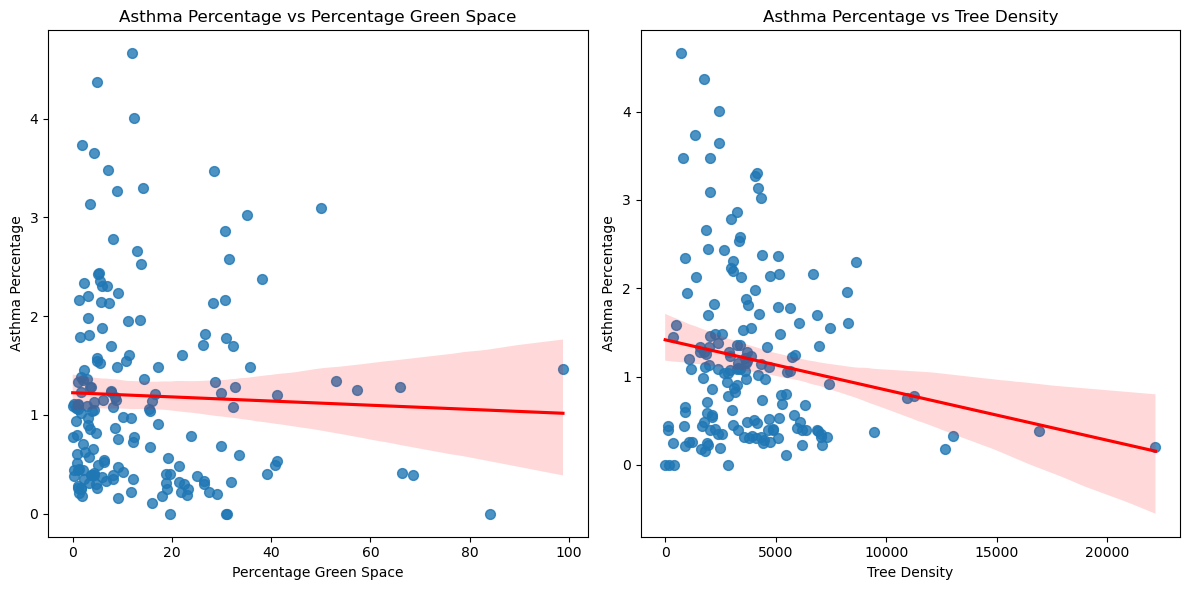

In [355]:
""" PLOTTING CORRELATIONS FOR NYC TOTAL """

# Plotting the graphs with line of best fit
plt.figure(figsize=(12, 6))

# Asthma Percentage vs Percentage Green Space
plt.subplot(1, 2, 1)
sns.regplot(x=df['GREENSPACE_PERCENT'], y=df['ASTHMA_PERCENT'], scatter_kws={'s': 50}, line_kws={"color": "red"})
plt.title('Asthma Percentage vs Percentage Green Space')
plt.xlabel('Percentage Green Space')
plt.ylabel('Asthma Percentage')

# Asthma Percentage vs Tree Density
plt.subplot(1, 2, 2)
sns.regplot(x=df['TREE_DENSITY'], y=df['ASTHMA_PERCENT'], scatter_kws={'s': 50}, line_kws={"color": "red"})
plt.title('Asthma Percentage vs Tree Density')
plt.xlabel('Tree Density')
plt.ylabel('Asthma Percentage')

plt.tight_layout()
plt.show()

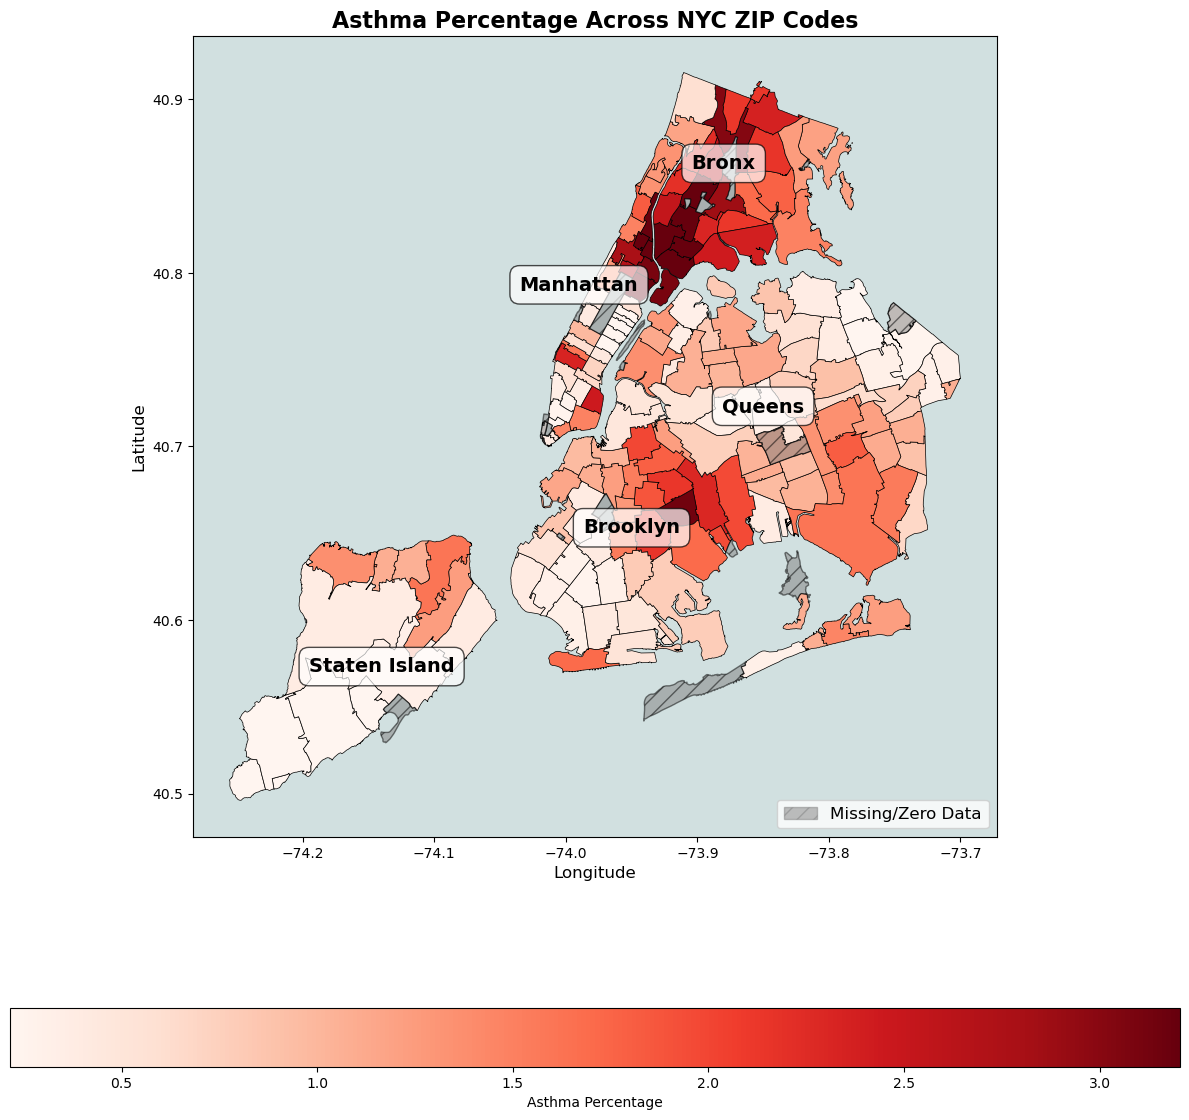

In [357]:
""" CREATING THE MAPS FOR NYC TOTAL (DISPLAYING ONLY ASTHMA) """

# Load the GeoJSON file containing zipcode boundaries
gdf = gpd.read_file('zip_areas.geojson')

# Load the merged asthma, green space, and tree density data
df_new = pd.read_csv('new_merged_data.csv')

# Ensure zipcoodes are strings
gdf['modzcta'] = gdf['modzcta'].astype(str)
df_new['ZIPCODE'] = df_new['ZIPCODE'].astype(str)

# Merge datasets
merged = gdf.merge(df_new, left_on='modzcta', right_on='ZIPCODE', how='left')

# Identify missing data
merged['has_missing'] = (merged['ASTHMA_PERCENT'].fillna(0) == 0) | (merged['GREENSPACE_PERCENT'].fillna(0) == 0) | (merged['TREE_DENSITY'].fillna(0) == 0)

# Define data ranges to avoid skewed coloring
vmin_asthma, vmax_asthma = merged['ASTHMA_PERCENT'].quantile([0.05, 0.95])
vmin_green, vmax_green = merged['GREENSPACE_PERCENT'].quantile([0.05, 0.95])
vmin_tree, vmax_tree = merged['TREE_DENSITY'].quantile([0.05, 0.95])

# NYC borough positions for labeling
borough_labels = {
    "Manhattan": (-73.99, 40.79),
    "Brooklyn": (-73.95, 40.65),
    "Queens": (-73.85, 40.72),
    "Bronx": (-73.88, 40.86),
    "Staten Island": (-74.14, 40.57)
}

# Function to plot map with borough labels, missing data overlay, and water background
def plot_map(column, cmap, title, legend_label, vmin, vmax, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_facecolor('#d1e0e0')  # Light blue background for water
    
    merged.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax,
                legend_kwds={'label': legend_label, 'orientation': "horizontal"}, edgecolor='black', linewidth=0.5)
    
    # Overlay gray hatched areas where data is missing
    merged[merged['has_missing']].plot(ax=ax, color='gray', hatch='//', alpha=0.5, edgecolor='black')
    
    # Add borough labels without covering data
    for borough, (x, y) in borough_labels.items():
        ax.text(x, y, borough, fontsize=14, fontweight='bold', color='black',
                ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.5'))
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(False)
    
    # Add legend for missing data
    missing_patch = mpatches.Patch(color='gray', alpha=0.5, hatch='//', label='Missing/Zero Data')
    ax.legend(handles=[missing_patch], loc='lower right', fontsize=12)
    
    # Save figure as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    # Display the figure
    plt.tight_layout()
    plt.show()

# Generate, save, and display maps
plot_map('ASTHMA_PERCENT', 'Reds', 'Asthma Percentage Across NYC ZIP Codes', 'Asthma Percentage', vmin_asthma, vmax_asthma, 'new_asthma_map.png')


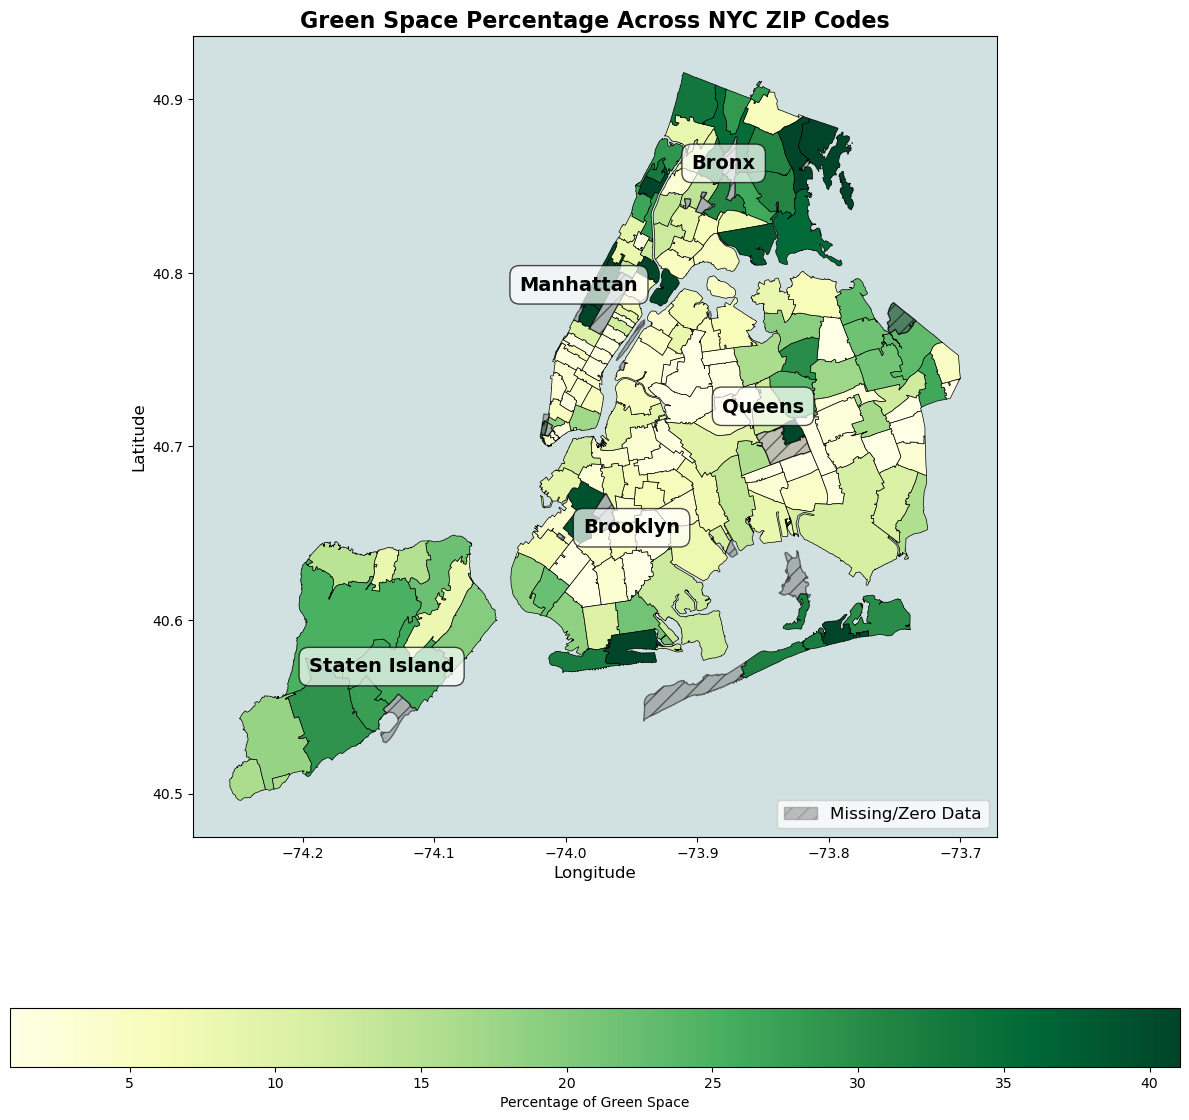

In [358]:
""" CALLING FUNCTION FOR CREATING GREEN SPACE MAP """

plot_map('GREENSPACE_PERCENT', 'YlGn', 'Green Space Percentage Across NYC ZIP Codes', 'Percentage of Green Space', vmin_green, vmax_green, 'new_green_map.png')

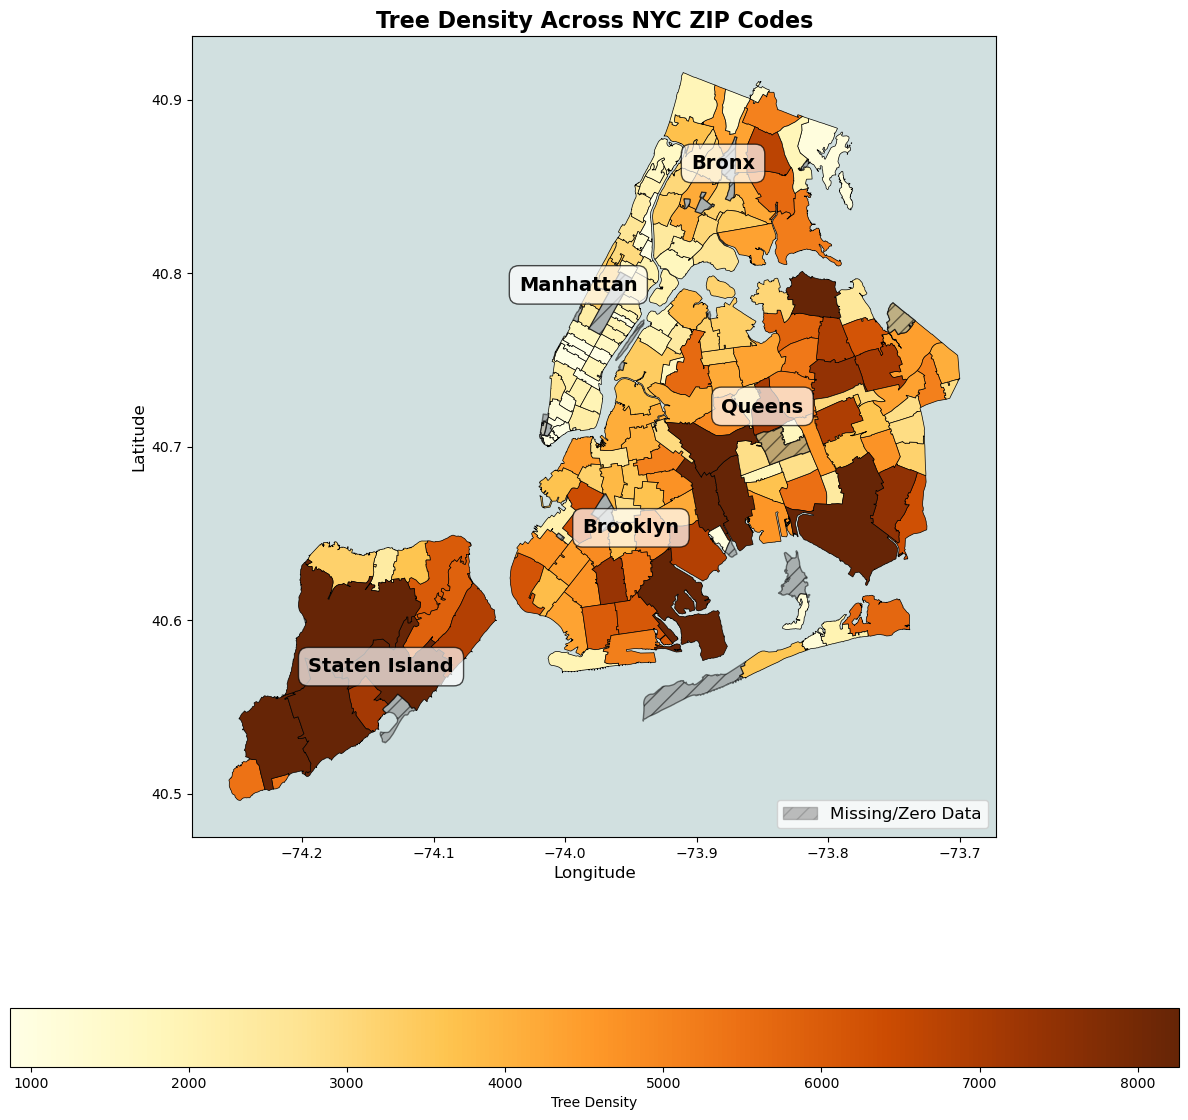

In [359]:
""" CALLING FUNCTION FOR CREATING TREE DENSITY MAP """

plot_map('TREE_DENSITY', 'YlOrBr', 'Tree Density Across NYC ZIP Codes', 'Tree Density', vmin_tree, vmax_tree, 'new_tree_map.png')

# The Bronx Correlations, Graphs, and Maps

## Corrleation between Asthma Percentage and Percentage Green Space in the Bronx: ***r*****(25) = -0.477, *****p***** = 0.016** *(Statistically Significant)*

## Correlation between Asthma Percentage and Tree Density in the Bronx: ***r*****(25) = -0.044, *****p***** = 0.8334** 

### [Back to the Top](#Milo-Powell,-Senior-Thesis-(May,-2025))

In [360]:
""" LOADING ALL CSV FILES """

# Load CSV Files
df_trees = pd.read_csv('street_trees.csv')
df_green_space = pd.read_csv('new_percentage_green_space.csv')
df_asthma = pd.read_csv('bronx_asthma.csv')

print(df_trees.head())
print(df_green_space.head())
print(df_asthma.head())

   tree_id  ZIPCODE
0   180683    11375
1   200540    11357
2   204026    11211
3   204337    11211
4   189565    11215
   ZIPCODE  PERCENTAGE_GREENSPACE
0    10001                   2.20
1    10002                  17.14
2    10003                   3.75
3    10004                   4.35
4    10005                   0.25
   ZIPCODE  PERCENT
0    10451     4.01
1    10452     2.53
2    10453     2.20
3    10454     4.37
4    10455     3.48


In [361]:
""" COMBINING ASTHMA PERCENTAGE WITH TREE DENSITY AND GREEN SPACE PERCENTAGE """

# Merge asthma CSV and merged green_space & tree_density CSV
bronx_merged_data = pd.merge(df_asthma, merged_data, on='ZIPCODE', how='inner')

# Save merged data to a new CSV to be used in analysis
bronx_merged_data.to_csv('asthma_greenspace_treedensity.csv', index=False)

# Rename columns for uniformity
bronx_merged_data.rename(columns={'PERCENT': 'ASTHMA_PERCENT', 'PERCENTAGE_GREENSPACE': 'GREENSPACE_PERCENT', 'tree_density': 'TREE_DENSITY'}, inplace=True)

# Save df as a new csv
bronx_merged_data.to_csv('bronx_merged_data.csv', index=False)

# View heading of merged data
print(bronx_merged_data.head())

   ZIPCODE  ASTHMA_PERCENT  GREENSPACE_PERCENT  TREE_DENSITY
0    10451            4.01               12.36        2450.0
1    10452            2.53               13.86        3320.0
2    10453            2.20                3.02        3050.0
3    10454            4.37                4.82        1755.0
4    10455            3.48                7.02        2044.0


In [364]:
""" RUNNING CORRELATIONS """

# Load csv 
df = pd.read_csv('bronx_merged_data.csv')

# Num of instances
num_instances = len(df)

# Correlation btwn green space and asthma in the bronx
corr_greenspace, p_value_greenspace = pearsonr(df['ASTHMA_PERCENT'], df['GREENSPACE_PERCENT'])

# Correlation btwn tree denisty and asthma in the bronx
corr_treedensity, p_value_treedensity = pearsonr(df['ASTHMA_PERCENT'], df['TREE_DENSITY'])

# Output the results
print(f"Num = {num_instances}")
print(f"Correlation between Asthma Percentage and Percentage Green Space: r = {corr_greenspace:.3f}, p-value = {p_value_greenspace:.3f}")
print(f"Correlation between Asthma Percentage and Tree Density: r = {corr_treedensity:.3f}, p-value = {p_value_treedensity:.3f}")

Num = 25
Correlation between Asthma Percentage and Percentage Green Space: r = -0.477, p-value = 0.016
Correlation between Asthma Percentage and Tree Density: r = -0.044, p-value = 0.833


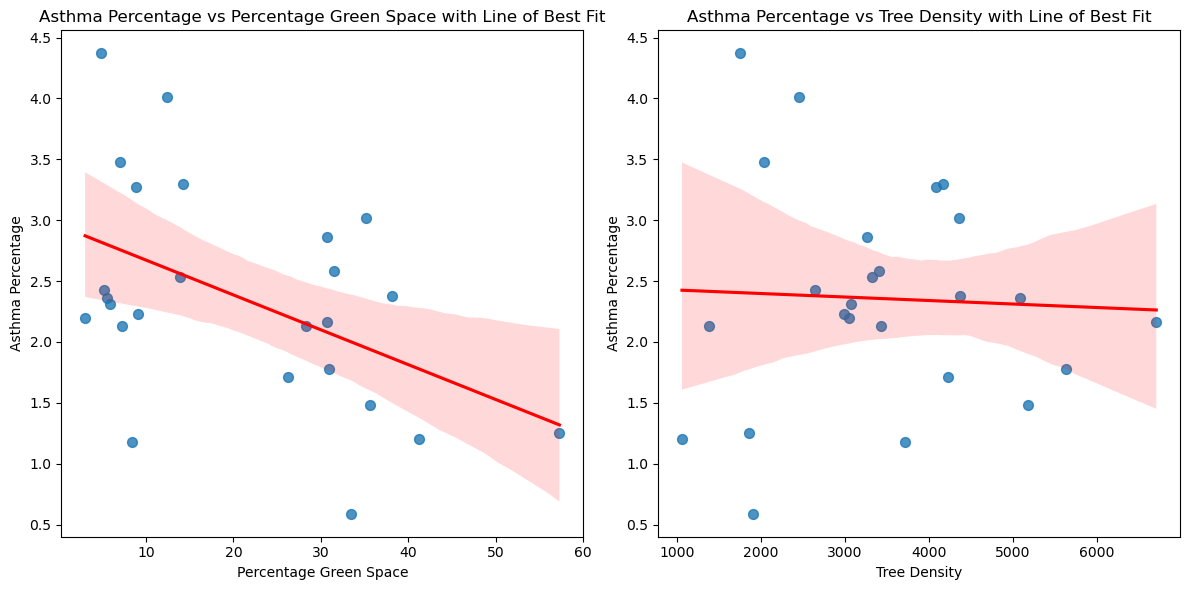

In [365]:
""" PLOTTING DATA """
# Plotting the graphs with line of best fit
plt.figure(figsize=(12, 6))

# Asthma Percentage vs Percentage Green Space
plt.subplot(1, 2, 1)
sns.regplot(x=df['GREENSPACE_PERCENT'], y=df['ASTHMA_PERCENT'], scatter_kws={'s': 50}, line_kws={"color": "red"})
plt.title('Asthma Percentage vs Percentage Green Space with Line of Best Fit')
plt.xlabel('Percentage Green Space')
plt.ylabel('Asthma Percentage')

# Asthma Percentage vs Tree Density
plt.subplot(1, 2, 2)
sns.regplot(x=df['TREE_DENSITY'], y=df['ASTHMA_PERCENT'], scatter_kws={'s': 50}, line_kws={"color": "red"})
plt.title('Asthma Percentage vs Tree Density with Line of Best Fit')
plt.xlabel('Tree Density')
plt.ylabel('Asthma Percentage')

plt.tight_layout()
plt.show()

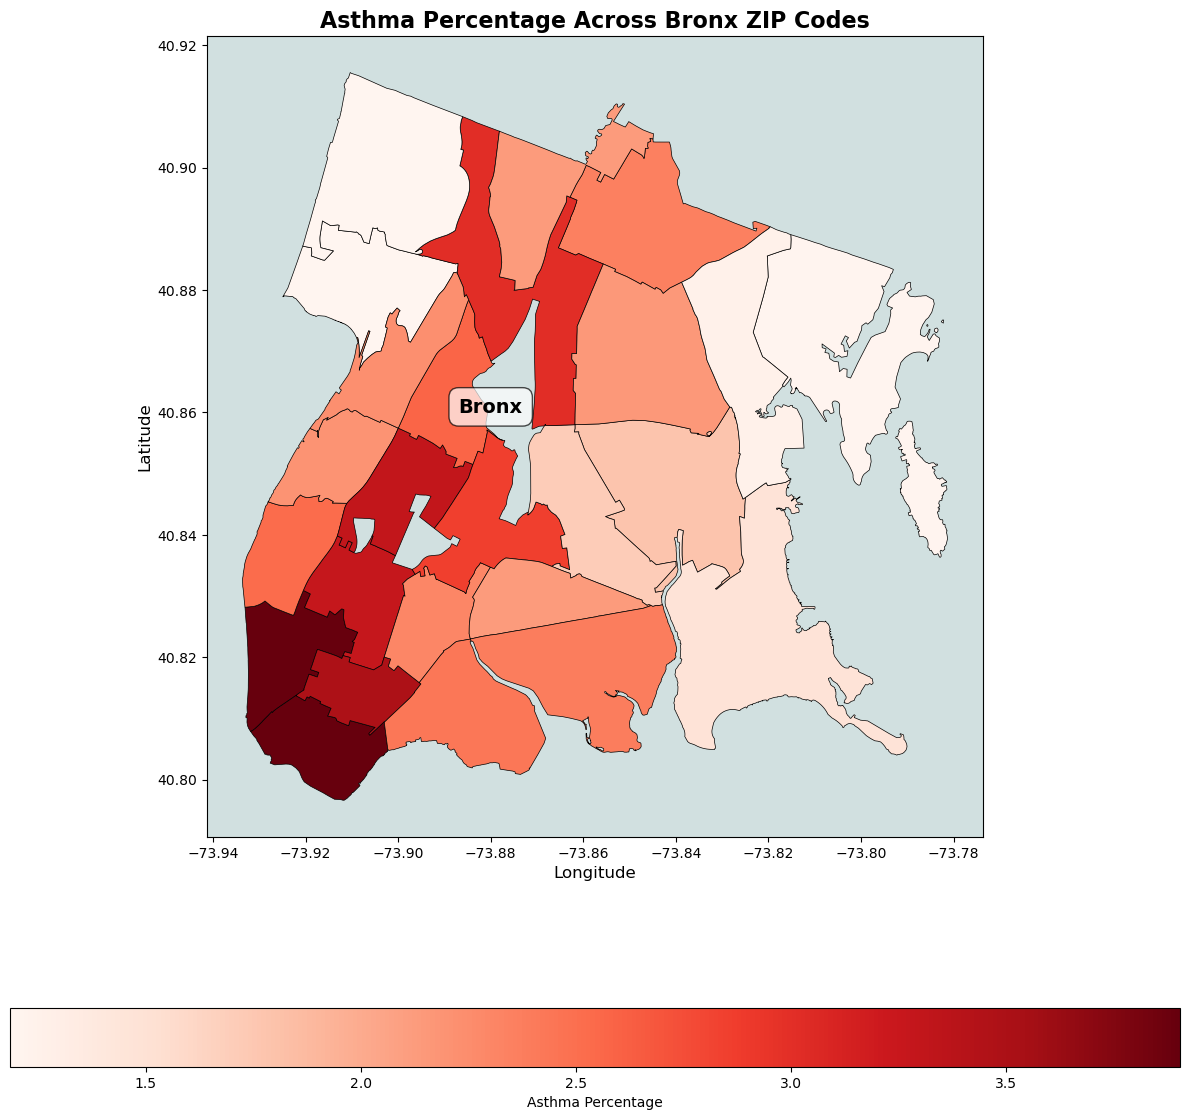

In [366]:
""" CREATING THE MAPS FOR THE BRONX (DISPLAYING ONLY ASTHMA) """

# Load the GeoJSON file containing zipcode boundaries
gdf = gpd.read_file('zip_areas.geojson')

# Load the merged asthma, green space, and tree density data
df_new = pd.read_csv('bronx_merged_data.csv')

# Ensure zipcoodes are strings
gdf['modzcta'] = gdf['modzcta'].astype(str)
df_new['ZIPCODE'] = df_new['ZIPCODE'].astype(str)

# Merge datasets
merged = gdf.merge(df_new, left_on='modzcta', right_on='ZIPCODE', how='inner')

# Identify missing data
merged['has_missing'] = (merged['ASTHMA_PERCENT'].fillna(0) == 0) | (merged['GREENSPACE_PERCENT'].fillna(0) == 0) | (merged['TREE_DENSITY'].fillna(0) == 0)

# Define data ranges to avoid skewed coloring
vmin_asthma, vmax_asthma = merged['ASTHMA_PERCENT'].quantile([0.05, 0.95])
vmin_green, vmax_green = merged['GREENSPACE_PERCENT'].quantile([0.05, 0.95])
vmin_tree, vmax_tree = merged['TREE_DENSITY'].quantile([0.05, 0.95])

# Bronx location for label
borough_labels = {
    "Bronx": (-73.88, 40.86)
}

# Function to plot map with borough label and water background
def plot_map(column, cmap, title, legend_label, vmin, vmax, filename):
    fig, ax = plt.subplots(1, 1, figsize=(12, 12))
    ax.set_facecolor('#d1e0e0')  # Light blue background for water
    
    merged.plot(column=column, ax=ax, legend=True, cmap=cmap, vmin=vmin, vmax=vmax,
                legend_kwds={'label': legend_label, 'orientation': "horizontal"}, edgecolor='black', linewidth=0.5)
    
    # Add borough label without covering data
    for borough, (x, y) in borough_labels.items():
        ax.text(x, y, borough, fontsize=14, fontweight='bold', color='black',
                ha='center', bbox=dict(facecolor='white', alpha=0.7, edgecolor='black', boxstyle='round,pad=0.5'))
    
    ax.set_title(title, fontsize=16, fontweight='bold')
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.grid(False)
    
    # Save figure as PNG
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    
    # Display the figure
    plt.tight_layout()
    plt.show()

# Generate, save, and display maps
plot_map('ASTHMA_PERCENT', 'Reds', 'Asthma Percentage Across Bronx ZIP Codes', 'Asthma Percentage', vmin_asthma, vmax_asthma, 'bronx_asthma_map.png')

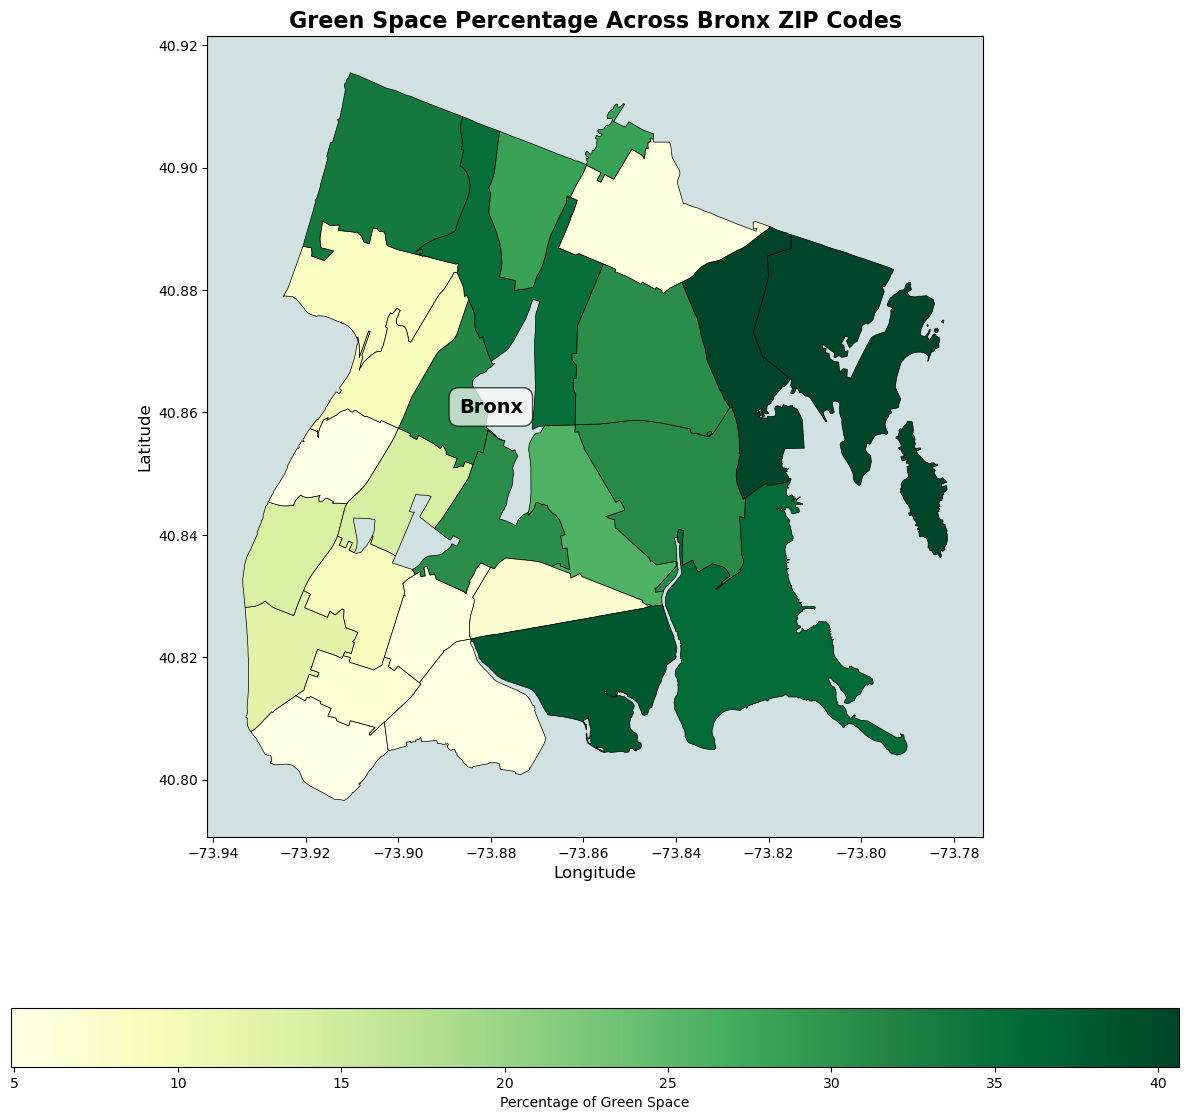

In [367]:
""" MAP FOR GREEN SPACE IN THE BRONX """

plot_map('GREENSPACE_PERCENT', 'YlGn', 'Green Space Percentage Across Bronx ZIP Codes', 'Percentage of Green Space', vmin_green, vmax_green, 'bronx_green_map.png')

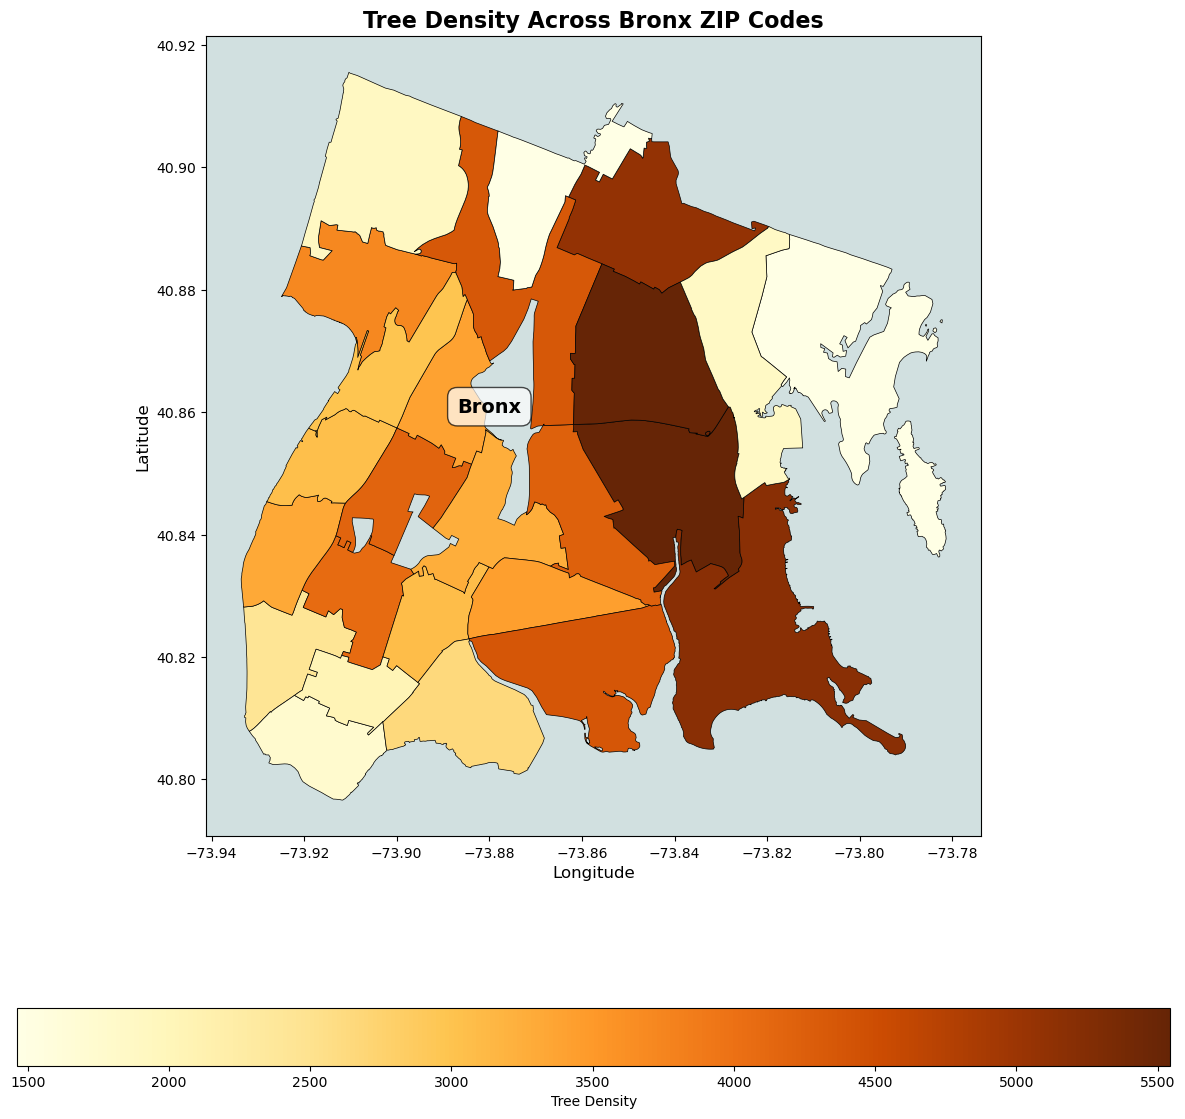

In [368]:
""" MAP FOR TREE DENSITY IN THE BRONX """

plot_map('TREE_DENSITY', 'YlOrBr', 'Tree Density Across Bronx ZIP Codes', 'Tree Density', vmin_tree, vmax_tree, 'bronx_tree_map.png')